In [1]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
img_dir = "../data/CrowdsourcingDataset-Amgadetal2019/images"
mask_dir = "../data/CrowdsourcingDataset-Amgadetal2019/masks"

filenames = sorted(os.listdir(img_dir))
print("Total pairs:", len(filenames))
print(filenames[:3])

Total pairs: 59
['TCGA-A1-A0SK-DX1_xmin45749_ymin25055_MPP-0.2500.png', 'TCGA-A1-A0SP-DX1_xmin6798_ymin53719_MPP-0.2500.png', 'TCGA-A2-A04P-DX1_xmin104246_ymin48517_MPP-0.2500.png']


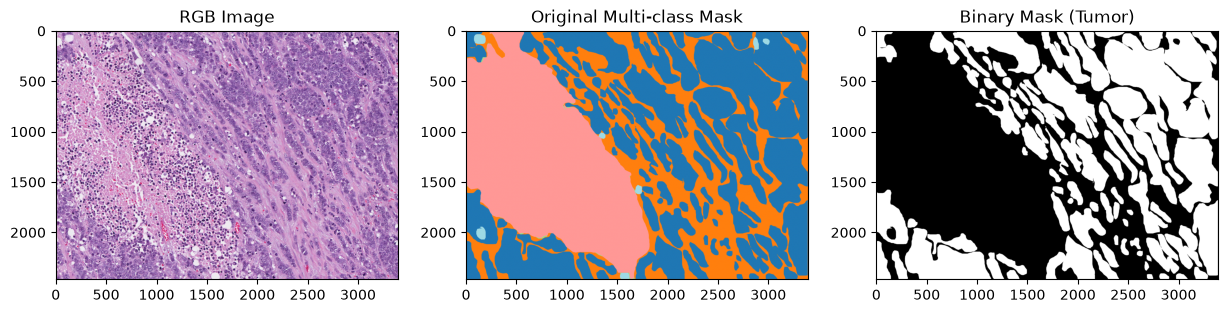

In [3]:
fname = filenames[0]

img = np.array(Image.open(os.path.join(img_dir, fname)))
mask = np.array(Image.open(os.path.join(mask_dir, fname)))

binary_mask = (mask == 1).astype(np.uint8)  # 1 = tumor, 0 = everything else

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img)
axes[0].set_title("RGB Image")
axes[1].imshow(mask, cmap="tab20")
axes[1].set_title("Original Multi-class Mask")
axes[2].imshow(binary_mask, cmap="gray")
axes[2].set_title("Binary Mask (Tumor)")
plt.show()

In [4]:
PATCH_SIZE = 256

def extract_patches(img, mask, patch_size=PATCH_SIZE, stride=None):
    if stride is None:
        stride = patch_size  # no overlap by default

    h, w = mask.shape
    img_patches = []
    mask_patches = []

    for y in range(0, h - patch_size + 1, stride):
        for x in range(0, w - patch_size + 1, stride):
            img_patch = img[y:y+patch_size, x:x+patch_size]
            mask_patch = mask[y:y+patch_size, x:x+patch_size]
            img_patches.append(img_patch)
            mask_patches.append(mask_patch)

    return img_patches, mask_patches

In [5]:
img_patches, mask_patches = extract_patches(img, binary_mask)
print("Number of patches from this one image:", len(img_patches))
print("Patch shape:", img_patches[0].shape, mask_patches[0].shape)

Number of patches from this one image: 117
Patch shape: (256, 256, 3) (256, 256)


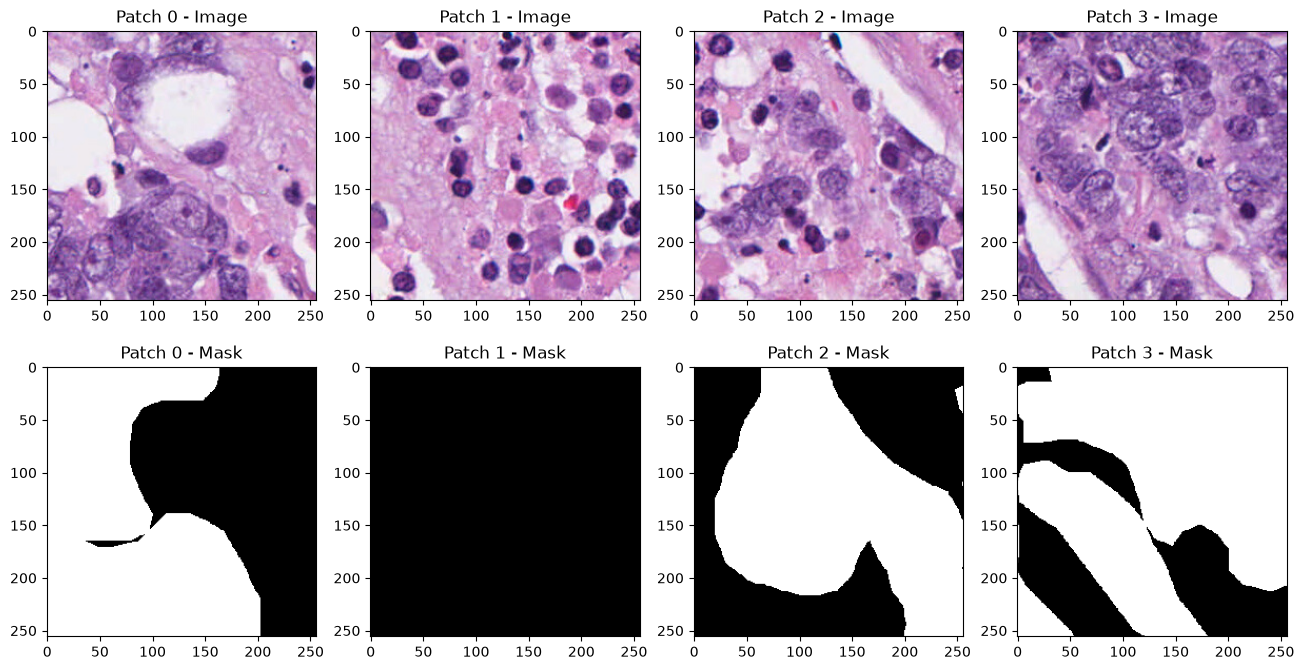

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    axes[0, i].imshow(img_patches[i])
    axes[0, i].set_title(f"Patch {i} - Image")
    axes[1, i].imshow(mask_patches[i], cmap="gray")
    axes[1, i].set_title(f"Patch {i} - Mask")
plt.show()

In [7]:
def is_mostly_background(img_patch, threshold=0.9):
    """Returns True if patch is mostly white/blank (no real tissue)."""
    gray = img_patch.mean(axis=2)  # average RGB to grayscale
    white_ratio = np.mean(gray > 220)  # fraction of near-white pixels
    return white_ratio > threshold

all_img_patches = []
all_mask_patches = []

for fname in filenames:
    img = np.array(Image.open(os.path.join(img_dir, fname)))
    mask = np.array(Image.open(os.path.join(mask_dir, fname)))
    binary_mask = (mask == 1).astype(np.uint8)

    img_patches, mask_patches = extract_patches(img, binary_mask)

    for ip, mp in zip(img_patches, mask_patches):
        if not is_mostly_background(ip):
            all_img_patches.append(ip)
            all_mask_patches.append(mp)

print("Total usable patches:", len(all_img_patches))

Total usable patches: 11875


In [8]:
tumor_pixel_ratios = [np.mean(m) for m in all_mask_patches]
patches_with_tumor = sum(1 for r in tumor_pixel_ratios if r > 0)

print("Patches with at least some tumor:", patches_with_tumor, "/", len(all_mask_patches))
print("Average tumor pixel ratio per patch:", np.mean(tumor_pixel_ratios))

Patches with at least some tumor: 8403 / 11875
Average tumor pixel ratio per patch: 0.44217408511513157


In [9]:
import numpy as np

os.makedirs("../data/patches/images", exist_ok=True)
os.makedirs("../data/patches/masks", exist_ok=True)

for i, (ip, mp) in enumerate(zip(all_img_patches, all_mask_patches)):
    Image.fromarray(ip).save(f"../data/patches/images/patch_{i:05d}.png")
    Image.fromarray(mp * 255).save(f"../data/patches/masks/patch_{i:05d}.png") 

print("Saved", len(all_img_patches), "patches to disk.")

Saved 11875 patches to disk.


In [10]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models.segmentation import deeplabv3_resnet50

In [11]:
class BCSSDataset(Dataset):
    def __init__(self, img_dir, mask_dir, filenames):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.filenames = filenames
        self.img_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                  std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        img = Image.open(os.path.join(self.img_dir, fname)).convert("RGB")
        mask = Image.open(os.path.join(self.mask_dir, fname)).convert("L")

        img = self.img_transform(img)
        mask = torch.tensor(np.array(mask) / 255, dtype=torch.float32).unsqueeze(0)

        return img, mask

In [12]:
patch_filenames = sorted(os.listdir("../data/patches/images"))

split = int(0.8 * len(patch_filenames))
train_files = patch_filenames[:split]
val_files = patch_filenames[split:]

train_dataset = BCSSDataset("../data/patches/images", "../data/patches/masks", train_files)
val_dataset = BCSSDataset("../data/patches/images", "../data/patches/masks", val_files)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print("Train patches:", len(train_dataset))
print("Val patches:", len(val_dataset))

Train patches: 9500
Val patches: 2375


In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = deeplabv3_resnet50(weights="DEFAULT")
model.classifier[4] = nn.Conv2d(256, 1, kernel_size=1)  # 1 output channel for binary
model = model.to(device)

Using device: cuda


In [14]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [15]:
def compute_metrics(pred, target, threshold=0.5, eps=1e-7):
    pred = (torch.sigmoid(pred) > threshold).float()

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection

    dice = (2 * intersection + eps) / (pred.sum() + target.sum() + eps)
    iou = (intersection + eps) / (union + eps)

    tp = intersection
    fp = (pred * (1 - target)).sum()
    fn = ((1 - pred) * target).sum()

    precision = (tp + eps) / (tp + fp + eps)
    recall = (tp + eps) / (tp + fn + eps)

    return dice.item(), iou.item(), precision.item(), recall.item()

In [16]:
num_epochs = 30

history = {
    "train_loss": [], "val_loss": [],
    "train_dice": [], "val_dice": [],
    "train_iou": [], "val_iou": [],
    "val_precision": [], "val_recall": []
}

best_val_dice = 0

for epoch in range(num_epochs):
    model.train()
    train_loss, train_dice, train_iou = 0, 0, 0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)['out']
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        d, i, _, _ = compute_metrics(outputs, masks)
        train_loss += loss.item()
        train_dice += d
        train_iou += i

    model.eval()
    val_loss, val_dice, val_iou, val_prec, val_rec = 0, 0, 0, 0, 0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)['out']
            loss = criterion(outputs, masks)

            d, i, p, r = compute_metrics(outputs, masks)
            val_loss += loss.item()
            val_dice += d
            val_iou += i
            val_prec += p
            val_rec += r

    n_train, n_val = len(train_loader), len(val_loader)
    history["train_loss"].append(train_loss / n_train)
    history["val_loss"].append(val_loss / n_val)
    history["train_dice"].append(train_dice / n_train)
    history["val_dice"].append(val_dice / n_val)
    history["train_iou"].append(train_iou / n_train)
    history["val_iou"].append(val_iou / n_val)
    history["val_precision"].append(val_prec / n_val)
    history["val_recall"].append(val_rec / n_val)

    current_val_dice = history["val_dice"][-1]

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {history['train_loss'][-1]:.4f} | Val Loss: {history['val_loss'][-1]:.4f} | "
          f"Train Dice: {history['train_dice'][-1]:.4f} | Val Dice: {current_val_dice:.4f} | "
          f"Val IoU: {history['val_iou'][-1]:.4f}")

    if current_val_dice > best_val_dice:
        best_val_dice = current_val_dice
        torch.save(model.state_dict(), "../notebooks/best_model.pth")

print(f"\nTraining complete. Best Val Dice achieved: {best_val_dice:.4f}")

Epoch 1/30 | Train Loss: 0.3633 | Val Loss: 0.3179 | Train Dice: 0.8235 | Val Dice: 0.7137 | Val IoU: 0.6233
Epoch 2/30 | Train Loss: 0.2966 | Val Loss: 0.3021 | Train Dice: 0.8587 | Val Dice: 0.7443 | Val IoU: 0.6668
Epoch 3/30 | Train Loss: 0.2684 | Val Loss: 0.3085 | Train Dice: 0.8732 | Val Dice: 0.7321 | Val IoU: 0.6467
Epoch 4/30 | Train Loss: 0.2430 | Val Loss: 0.3256 | Train Dice: 0.8835 | Val Dice: 0.6796 | Val IoU: 0.5964
Epoch 5/30 | Train Loss: 0.2291 | Val Loss: 0.3100 | Train Dice: 0.8910 | Val Dice: 0.6939 | Val IoU: 0.6082
Epoch 6/30 | Train Loss: 0.2043 | Val Loss: 0.3659 | Train Dice: 0.9018 | Val Dice: 0.6512 | Val IoU: 0.5638
Epoch 7/30 | Train Loss: 0.1971 | Val Loss: 0.3070 | Train Dice: 0.9069 | Val Dice: 0.7246 | Val IoU: 0.6417
Epoch 8/30 | Train Loss: 0.1764 | Val Loss: 0.2906 | Train Dice: 0.9161 | Val Dice: 0.6940 | Val IoU: 0.6122
Epoch 9/30 | Train Loss: 0.1767 | Val Loss: 0.2886 | Train Dice: 0.9150 | Val Dice: 0.7169 | Val IoU: 0.6317
Epoch 10/30 | Train

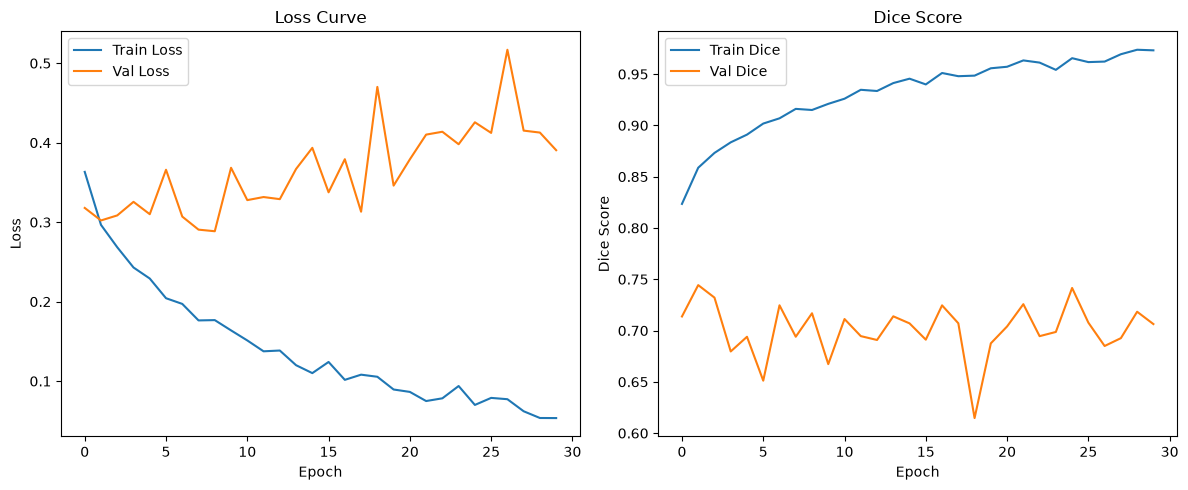

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"], label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curve")
axes[0].legend()

axes[1].plot(history["train_dice"], label="Train Dice")
axes[1].plot(history["val_dice"], label="Val Dice")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Dice Score")
axes[1].set_title("Dice Score")
axes[1].legend()

plt.tight_layout()
plt.show()

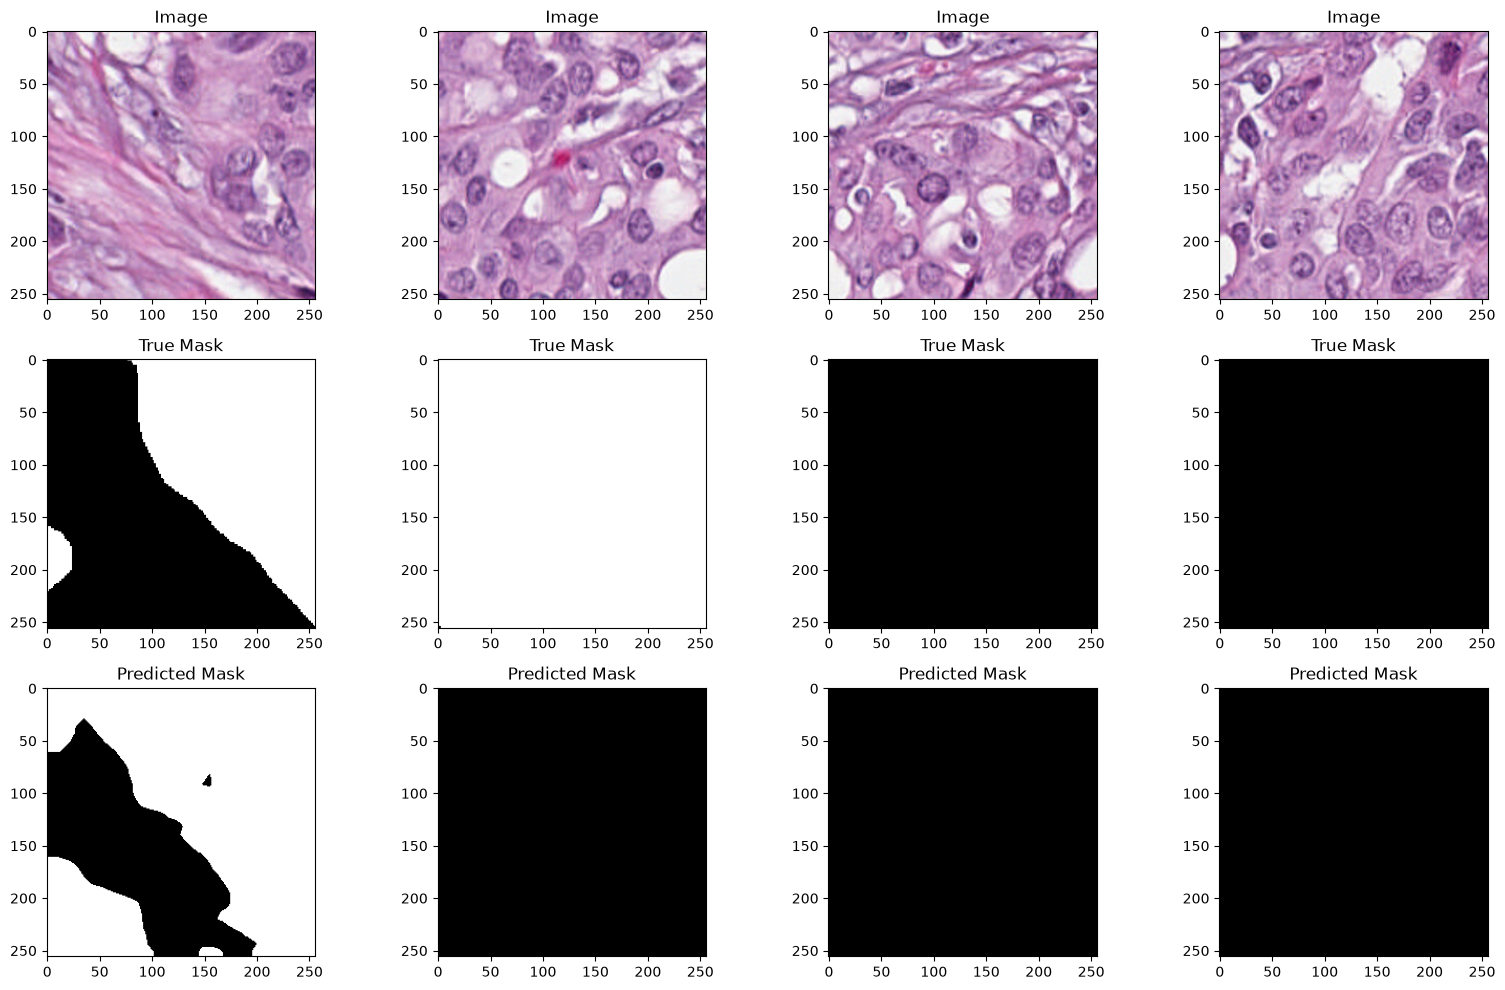

In [20]:
best_model = deeplabv3_resnet50(weights="DEFAULT")
best_model.classifier[4] = nn.Conv2d(256, 1, kernel_size=1)
best_model.load_state_dict(torch.load("../notebooks/best_model.pth"))
best_model = best_model.to(device)
best_model.eval()

imgs, masks = next(iter(val_loader))
imgs, masks = imgs.to(device), masks.to(device)

with torch.no_grad():
    preds = torch.sigmoid(best_model(imgs)['out']) > 0.5

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for i in range(4):
    img_disp = imgs[i].cpu().permute(1,2,0).numpy()
    img_disp = img_disp * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])
    img_disp = np.clip(img_disp, 0, 1)

    axes[0, i].imshow(img_disp)
    axes[0, i].set_title("Image")
    axes[1, i].imshow(masks[i].cpu().squeeze(), cmap="gray")
    axes[1, i].set_title("True Mask")
    axes[2, i].imshow(preds[i].cpu().squeeze(), cmap="gray")
    axes[2, i].set_title("Predicted Mask")
plt.tight_layout()
plt.show()

In [21]:
imgs, masks = next(iter(val_loader))
imgs, masks = imgs.to(device), masks.to(device)

with torch.no_grad():
    preds = torch.sigmoid(best_model(imgs)['out']) > 0.5

for i in range(len(imgs)):
    true_tumor_ratio = masks[i].mean().item()
    pred_tumor_ratio = preds[i].float().mean().item()
    print(f"Sample {i}: True tumor ratio={true_tumor_ratio:.2f}, Predicted tumor ratio={pred_tumor_ratio:.2f}")

Sample 0: True tumor ratio=0.45, Predicted tumor ratio=0.68
Sample 1: True tumor ratio=1.00, Predicted tumor ratio=1.00
Sample 2: True tumor ratio=1.00, Predicted tumor ratio=1.00
Sample 3: True tumor ratio=1.00, Predicted tumor ratio=1.00
Sample 4: True tumor ratio=1.00, Predicted tumor ratio=0.98
Sample 5: True tumor ratio=0.93, Predicted tumor ratio=1.00
Sample 6: True tumor ratio=0.54, Predicted tumor ratio=1.00
Sample 7: True tumor ratio=0.68, Predicted tumor ratio=1.00


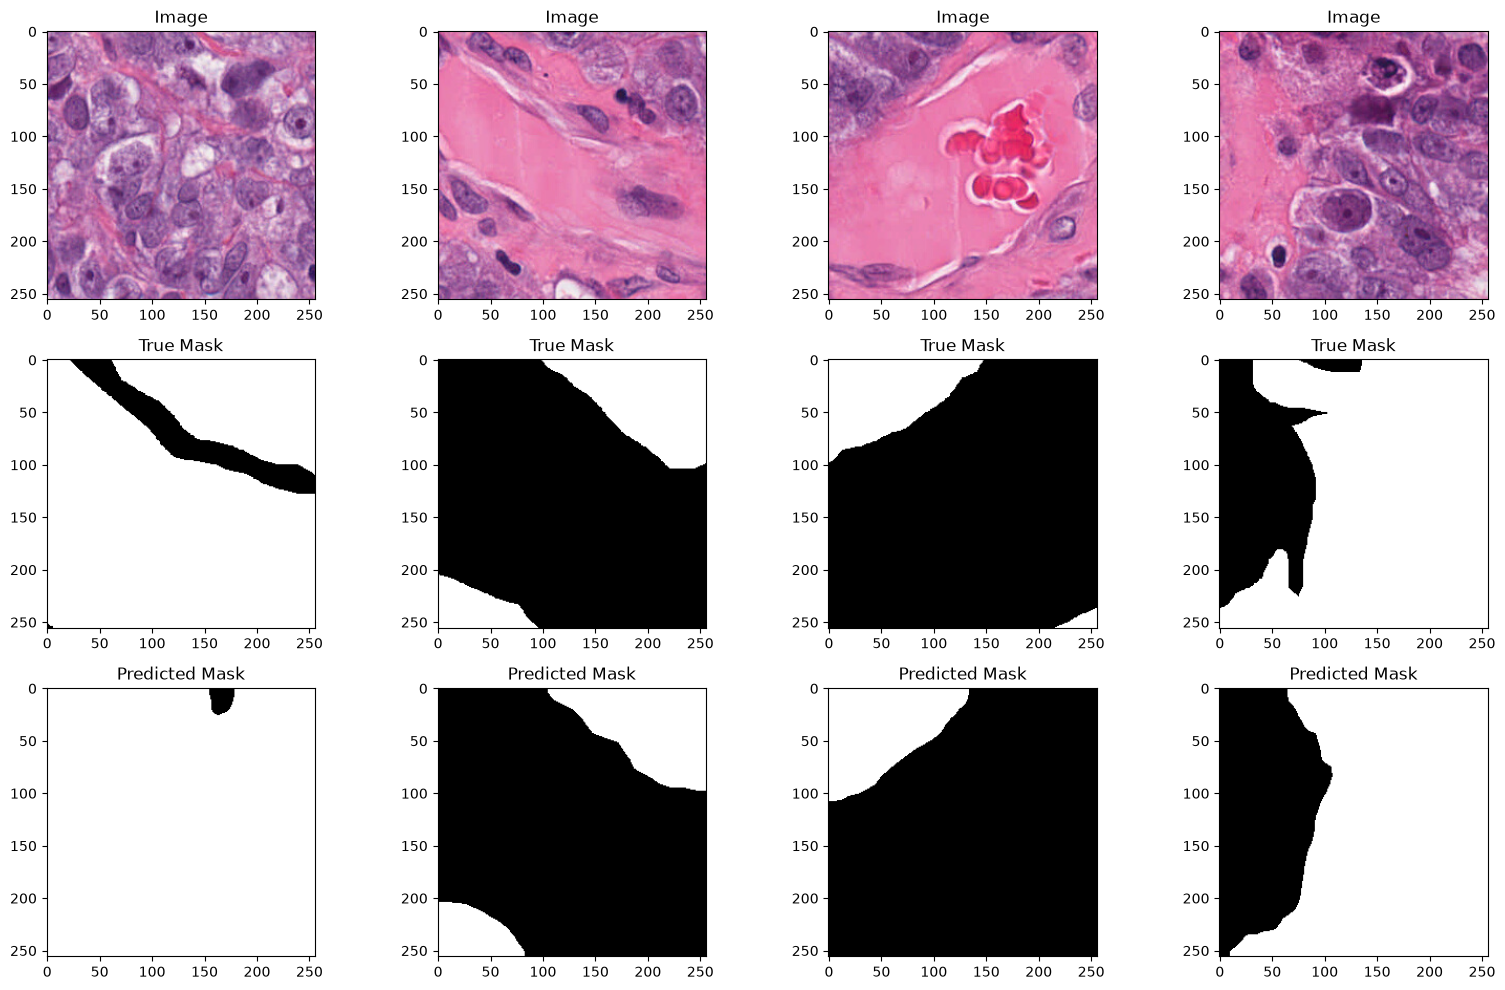

In [26]:
import random

best_model = deeplabv3_resnet50(weights="DEFAULT")
best_model.classifier[4] = nn.Conv2d(256, 1, kernel_size=1)
best_model.load_state_dict(torch.load("../notebooks/best_model.pth"))
best_model = best_model.to(device)
best_model.eval()

val_iter = iter(val_loader)
skip_batches = random.randint(0, len(val_loader) - 1)
for _ in range(skip_batches):
    next(val_iter)

imgs, masks = next(val_iter)
imgs, masks = imgs.to(device), masks.to(device)

with torch.no_grad():
    preds = torch.sigmoid(best_model(imgs)['out']) > 0.5

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for i in range(4):
    img_disp = imgs[i].cpu().permute(1,2,0).numpy()
    img_disp = img_disp * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])
    img_disp = np.clip(img_disp, 0, 1)

    axes[0, i].imshow(img_disp)
    axes[0, i].set_title("Image")
    axes[1, i].imshow(masks[i].cpu().squeeze(), cmap="gray")
    axes[1, i].set_title("True Mask")
    axes[2, i].imshow(preds[i].cpu().squeeze(), cmap="gray")
    axes[2, i].set_title("Predicted Mask")

plt.tight_layout()
plt.savefig("../notebooks/prediction_results.png", dpi=150, bbox_inches="tight")
plt.show()